# Trabajo Práctico — Machine Learning Engineering
## Predicción del precio de venta de propiedades en Capital Federal

**Dataset:** `properati.csv` — publicaciones de propiedades en Argentina.

**Objetivo:** aplicar el ciclo completo de un proyecto de Machine Learning: exploración, preprocesamiento, transformación, modelado y evaluación, para predecir el precio de venta de propiedades en Capital Federal.

> Las decisiones tomadas a lo largo del trabajo están justificadas en celdas de Markdown.

---

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 60)

RANDOM_STATE = 42
df_raw = pd.read_csv("properati.csv")
df_raw.shape

(992192, 25)

In [2]:
df_raw.head()

,id,ad_type,start_date,end_date,created_on,lat,lon,l1,l2,l3,l4,l5,l6,rooms,bedrooms,bathrooms,surface_total,surface_covered,currency,price_period,title,description,property_type,operation_type,price
0,556713,Propiedad,2019-11-29,9999-12-31,2019-11-29,-58.442399,-34.573623,Argentina,Capital Federal,Colegiales,NaN,NaN,NaN,3.0,2.0,2.0,NaN,NaN,USD,NaN,"Departamento en Venta en Belgrano, Capital fed...","Sup total por escritura: 96,47 m2 (cubiertos: ...",Departamento,Venta,259000.0
1,192912,Propiedad,2020-06-05,2020-06-08,2020-06-05,-58.430493,-34.606620,Argentina,Capital Federal,Almagro,NaN,NaN,NaN,3.0,2.0,2.0,77.0,67.0,USD,NaN,Departamento de 3 ambientes en Venta en Almagro,Excelente departamento de tres ambientes ampli...,Departamento,Venta,235500.0
2,238224,Propiedad,2020-07-01,9999-12-31,2020-07-01,-58.491760,-34.574123,Argentina,Capital Federal,Villa Urquiza,NaN,NaN,NaN,2.0,NaN,1.0,60.0,55.0,USD,NaN,Andonaegui 2600 4° - - Departamento en Venta,Excelente 3 ambientes al frente con balcón. Vi...,Departamento,Venta,175000.0
3,257134,Propiedad,2019-08-17,9999-12-31,2019-08-17,-58.420737,-34.631770,Argentina,Capital Federal,Boedo,NaN,NaN,NaN,2.0,1.0,1.0,74.0,47.0,USD,NaN,PH Venta Boedo 2 amb Patio,Corredor Responsable: MARCELO TRUJILLO - CPI ...,PH,Venta,140000.0
4,521738,Propiedad,2019-08-05,2019-08-31,2019-08-05,-58.429983,-34.607225,Argentina,Capital Federal,Almagro,NaN,NaN,NaN,3.0,2.0,1.0,66.0,64.0,USD,NaN,Venta 3 Ambientes - Almagro - Balcón - Ameniti...,Corredor Responsable: Marcelo Trujillo - CUCIC...,Departamento,Venta,173000.0


In [3]:
resumen = pd.DataFrame({
    "dtype": df_raw.dtypes,
    "nulos": df_raw.isna().sum(),
})
resumen["% nulos"] = (resumen["nulos"] / len(df_raw) * 100).round(2)
resumen.sort_values("% nulos", ascending=False)

,dtype,nulos,% nulos
l6,float64,992192,100.00
l5,str,987481,99.53
l4,str,766797,77.28
price_period,str,622253,62.71
bedrooms,float64,601493,60.62
surface_covered,float64,555231,55.96
surface_total,float64,544028,54.83
rooms,float64,489147,49.30
bathrooms,float64,219171,22.09
lat,float64,153198,15.44


### Decisiones de alcance previas a explorar

1. **Filtrar por `l2 == "Capital Federal"`**: el objetivo del TP es predecir precios *en Capital Federal*. Mezclar otras provincias introduce variación de precio por mercado (distinta demanda, distinta moneda de referencia) que no queremos modelar.
2. **Filtrar por `operation_type == "Venta"`**: hay publicaciones de alquiler y alquiler temporal. La variable objetivo es precio de *venta*; alquilar y vender son problemas distintos y las columnas no son comparables entre sí.
3. **Filtrar por `currency == "USD"`**: en el dataset conviven USD, ARS y nulls. En CABA/Venta: 169.054 USD, 1.742 ARS y 6.315 sin moneda. Convertir ARS a USD exigiría un tipo de cambio histórico por fecha de publicación (no disponible y sujeto a brecha cambiaria). Descartar esos ~8k registros (menos del 5%) es más limpio que una conversión aproximada.
4. **Se descartan `l4`, `l5`, `l6`**: 77%, 99% y 100% nulos respectivamente; no aportan.
5. **Se descartan `title` y `description`**: texto libre con encoding dañado. Podrían usarse con NLP, pero está fuera del alcance del TP y no aportan a un modelo tabular básico.

In [4]:
print("Antes del filtro:", df_raw.shape)

df = df_raw[
    (df_raw["l2"] == "Capital Federal")
    & (df_raw["operation_type"] == "Venta")
    & (df_raw["currency"] == "USD")
].copy()

print("Después del filtro (CABA + Venta + USD):", df.shape)
print()
print("Precio (USD):")
print(df["price"].describe())

Antes del filtro: (992192, 25)
Después del filtro (CABA + Venta + USD): (169054, 25)

Precio (USD):
count    1.690540e+05
mean     2.854579e+05
std      5.007156e+05
min      1.100000e+01
25%      1.000000e+05
50%      1.600000e+05
75%      2.803200e+05
max      3.243423e+07
Name: price, dtype: float64


---

## Parte 1 a) — Visualización de los datos

Seis gráficos, cada uno con una pregunta distinta:

| # | Gráfico | Pregunta que responde |
|---|---------|----------------------|
| 1 | Histograma de precio (log) | ¿Cómo es la distribución? ¿Hay sesgo/colas largas? |
| 2 | Conteo por tipo de propiedad | ¿Está balanceado el dataset por tipo? |
| 3 | Boxplot de precio por tipo | ¿Cambia el rango de precios entre tipos? |
| 4 | Scatter superficie vs precio | ¿Hay relación (semi)lineal? ¿Homocedasticidad? |
| 5 | Matriz de correlación | ¿Qué numéricas están linealmente relacionadas? |
| 6 | Mapa geográfico (lat/lon) | ¿El espacio explica precio? |

### Gráfico 1 — Distribución de precios (histograma, escala logarítmica)

**Por qué:** el precio es la variable objetivo. Conocer su distribución define casi todo lo demás: qué métrica conviene (si hay cola larga, el RMSE la penaliza de más), si conviene escalar o transformar, y si hay valores absurdos.

**Qué espero descubrir:** precios inmobiliarios suelen tener distribución sesgada a la derecha (pocas propiedades muy caras). La escala logarítmica permite ver la forma real de la cola.

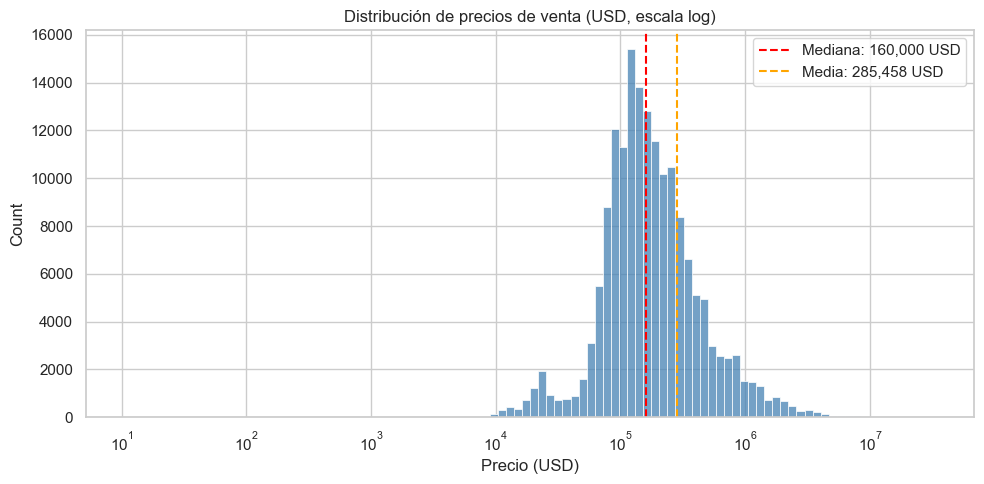

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
precios = df.loc[df["price"] > 0, "price"]

sns.histplot(precios, bins=100, log_scale=True, ax=ax, color="steelblue")
ax.axvline(precios.median(), color="red", ls="--", label=f"Mediana: {precios.median():,.0f} USD")
ax.axvline(precios.mean(), color="orange", ls="--", label=f"Media: {precios.mean():,.0f} USD")

ax.set_title("Distribución de precios de venta (USD, escala log)")
ax.set_xlabel("Precio (USD)")
ax.legend()
plt.tight_layout()
plt.show()

**Qué descubrí:**
- Distribución **sesgada a la derecha**: mediana 160.000 USD vs media 285.000 USD. La media la tiran las pocas propiedades muy caras.
- Cola derecha que llega hasta ~30 millones de USD.
- Pico secundario alrededor de 10.000–40.000 USD: probablemente cocheras, cocheras y locales chicos mezclados en la misma distribución.
- **Implicancia para el TP:** la distribución no es simétrica. Eso favorece una métrica robusta como MAE (no la media de errores al cuadrado, muy sensible a la cola) y abre la puerta a modelar `log(price)` en vez de `price` crudo.

### Gráfico 2 — Cantidad de publicaciones por tipo de propiedad

**Por qué:** `property_type` es una categórica con alta probabilidad de ser feature. Antes de usarla, hay que saber si todos los tipos tienen muestra suficiente.

**Qué espero descubrir:** si el dataset está dominado por departamentos, y si hay tipos con tan pocos registros que convenga agruparlos o descartarlos.

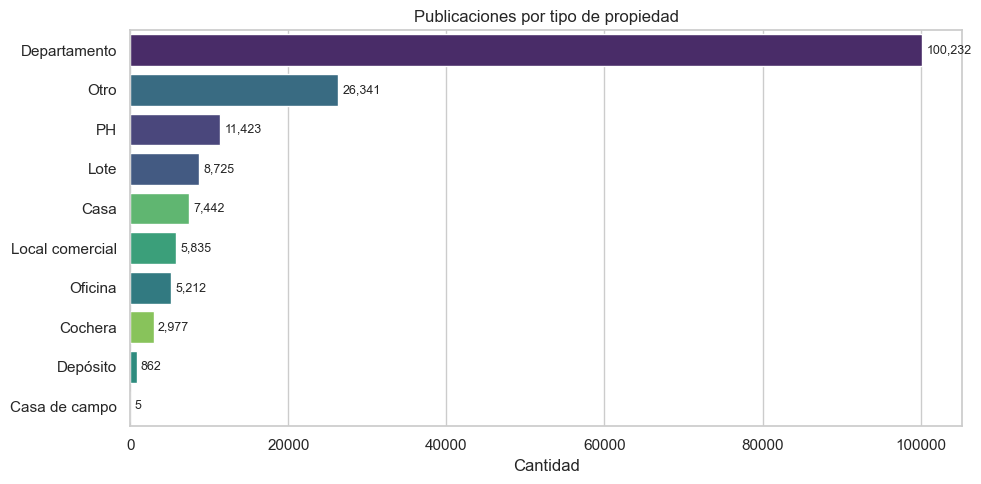

In [6]:
orden = df["property_type"].value_counts().index

fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(data=df, y="property_type", order=orden, hue="property_type",
              palette="viridis", legend=False, ax=ax)
ax.set_title("Publicaciones por tipo de propiedad")
ax.set_xlabel("Cantidad")
ax.set_ylabel("")
for i, v in enumerate(df["property_type"].value_counts()):
    ax.text(v + 500, i, f"{v:,}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

**Qué descubrí:**
- **Departamento domina**: 100.232 de 169.054 publicaciones (~59%). El dataset está desbalanceado por tipo.
- `Otro` es la segunda categoría (26.341) pero es una **categoría-vertedero**: no define un tipo de propiedad. Candidata a descarte o a reasignación.
- `Casa de campo` tiene **5 registros**: no alcanza para aprender nada. Se descarta.
- El resto tiene muestra suficiente (≥ 862), aunque `Depósito` y `Cochera` quedan como tipos minoritarios.

### Gráfico 3 — Distribución de precios por tipo de propiedad (boxplot)

**Por qué:** compara la variable objetivo entre categorías. Si los rangos no se solapan, el tipo de propiedad es predictiva fuerte.

**Qué espero descubrir:** si un "Casa" y un "Cochera" viven en universos de precio distintos; si hay outliers dentro de cada tipo.

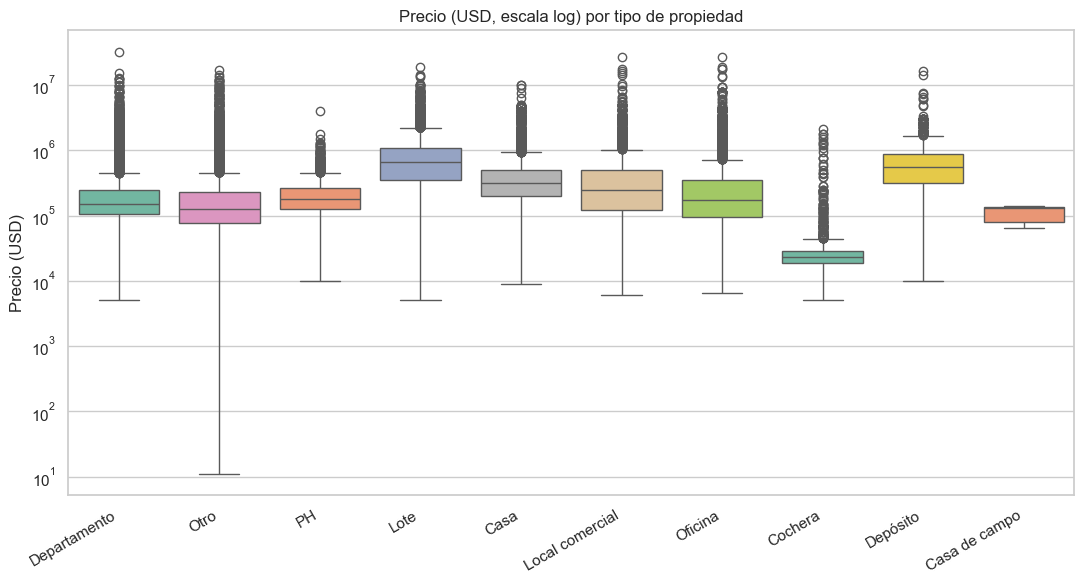

In [7]:
tipos = df["property_type"].value_counts().index.tolist()

fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(data=df, x="property_type", y="price", order=tipos,
            hue="property_type", palette="Set2", legend=False, ax=ax)
ax.set_yscale("log")
ax.set_title("Precio (USD, escala log) por tipo de propiedad")
ax.set_xlabel("")
ax.set_ylabel("Precio (USD)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

**Qué descubrí:**
- **Medianas muy distintas por tipo**: cochera ~25.000 USD, departamento ~160.000 USD, depósito/lote ~500.000 USD. `property_type` es una feature de primer nivel.
- **Outliers en todos los tipos**: casi todos superan 1.000.000 USD arriba de su caja. Son en parte reales (penthouses, casas premium) y en parte errores de carga.
- `Otro` llega a **11 USD**: imposible. O error de carga, o "precio a convenir" cargado como número. Se revisa en el punto 1b.1 (datos mal ingresados).
- Los rangos de `Cochera` y `Depósito` casi no se solapan con los de `Departamento`: ignorar `property_type` sería un error grave.

### Gráfico 4 — Relación superficie cubierta vs precio (muestra)

**Por qué:** superficie y precio son las dos variables numéricas centrales del problema. Un scatter muestra la forma de la relación: si es lineal, si la varianza crece con el precio (heterocedasticidad), y si hay puntos imposibles (supertotal vs precio).

**Qué espero descubrir:** se espera correlación positiva, con nubes de puntos alejados (ph/locales) y valores de superficie absurdos.

> Se grafica una **muestra aleatoria de 5.000 puntos**: con 160k+ puntos el scatter queda como mancha sólida y no se ve nada (overplotting). La semilla fija hace el gráfico reproducible.

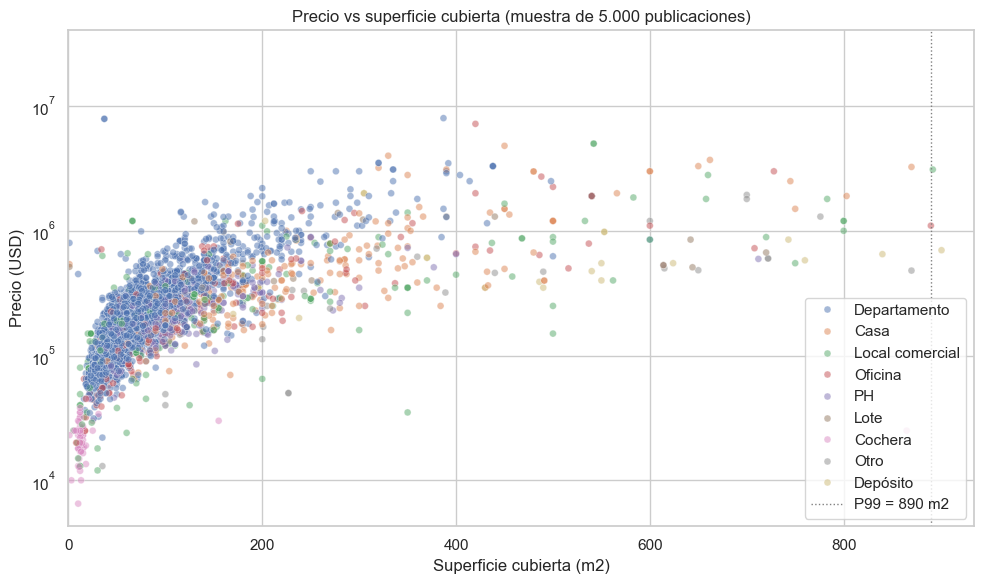

In [8]:
muestra = df.dropna(subset=["surface_covered", "price"]).sample(
    n=5000, random_state=RANDOM_STATE
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=muestra, x="surface_covered", y="price",
                hue="property_type", alpha=0.5, s=25, ax=ax)
ax.set_title("Precio vs superficie cubierta (muestra de 5.000 publicaciones)")
ax.set_xlabel("Superficie cubierta (m2)")
ax.set_ylabel("Precio (USD)")
ax.set_yscale("log")

# Los outliers de superficie (hay superficies de >60.000 m2) aplastan el eje X.
# Se recorta la vista al percentil 99 para poder ver la forma de la nube de puntos.
p99 = muestra["surface_covered"].quantile(0.99)
ax.set_xlim(0, p99 * 1.05)
ax.axvline(p99, color="gray", ls=":", lw=1, label=f"P99 = {p99:.0f} m2")
ax.legend()
plt.tight_layout()
plt.show()

**Qué descubrí:**
- Relación **positiva pero ruidosa**: a más superficie, más precio, con mucha dispersión.
- **Heterocedasticidad**: la dispersión del precio crece con la superficie (y con el precio mismo). Esto castiga a la Regresión Lineal en los valores altos.
- El primer intento de este gráfico fue **ilegible**: un outlier de 63.000 m2 comprimía todo el eje X. Recortar la vista al P99 (línea punteada) hizo visible la forma real. Los outliers siguen existiendo en el dataset: esto es solo una decisión de visualización, no de limpieza.
- Hay puntos con superficie casi 0: otro indicio de datos mal cargados para la parte 1b.

### Gráfico 5 — Matriz de correlación de las numéricas

**Por qué:** detecta colinealidad. Si dos features se corrrelacionan fuerte entre sí, la Regresión Lineal se vuelve inestable (coeficientes inflados); con Random Forest no es problema, pero sirve para decidir qué variables descartar.

**Qué espero descubrir:** `rooms`/`bedrooms`/`bathrooms` seguramente correlacionen entre sí; `surface_total` y `surface_covered` también. Ahí hay candidatas a descarte o a feature engineering.

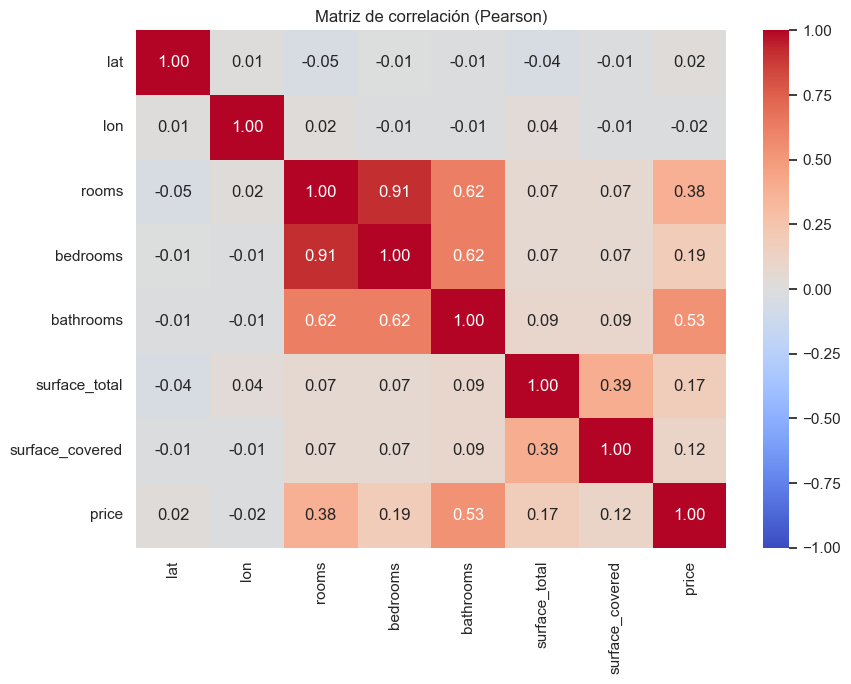

In [9]:
numericas = ["lat", "lon", "rooms", "bedrooms", "bathrooms",
             "surface_total", "surface_covered", "price"]

corr = df[numericas].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Matriz de correlación (Pearson)")
plt.tight_layout()
plt.show()

**Qué descubrí:**
- `rooms` vs `bedrooms`: **0,91**. Casi la misma información. Para la Regresión Lineal eso es multicolinealidad (coeficientes inestables); conviene quedarse con una o combinarlas. Para Random Forest no molesta tanto.
- `bathrooms` es la numérica que **más correlaciona con precio (0,53)** — más que superficie.
- `surface_total`/`surface_covered` correlacionan flojo con precio (0,17 / 0,12): Pearson en crudo los hunde por los outliers extremos y por tener ~55% de nulos. No significa que no sirvan; significa que la relación no es lineal pura.
- `lat`/`lon` dan ~0 con precio. **No significa que la ubicación no importe**: significa que la relación entre ubicación y precio no es lineal (es espacial). El gráfico 6 lo muestra. (Además, como se descubrió después, esas columnas están invertidas — ver gráfico 6.)

### Gráfico 6 — Mapa geográfico de precios (lat/lon)

**Por qué:** la ubicación es el factor clásico del valor inmobiliario. Un scatter espacial permite ver si el precio tiene estructura geográfica, algo que las numéricas solas no muestran.

**Qué espero descubrir:** focos caros (Palermo, Recoleta, Puerto Madero), zona sur más barata, y posibles coordenadas mal cargadas (fueras de CABA).

lat (crudo) rango: -71.6580585 a -53.8285784574
lon (crudo) rango: -53.788249 a 1.0
Publicaciones con coordenadas fuera de CABA: 1,849 de 144,830 (1.3%)


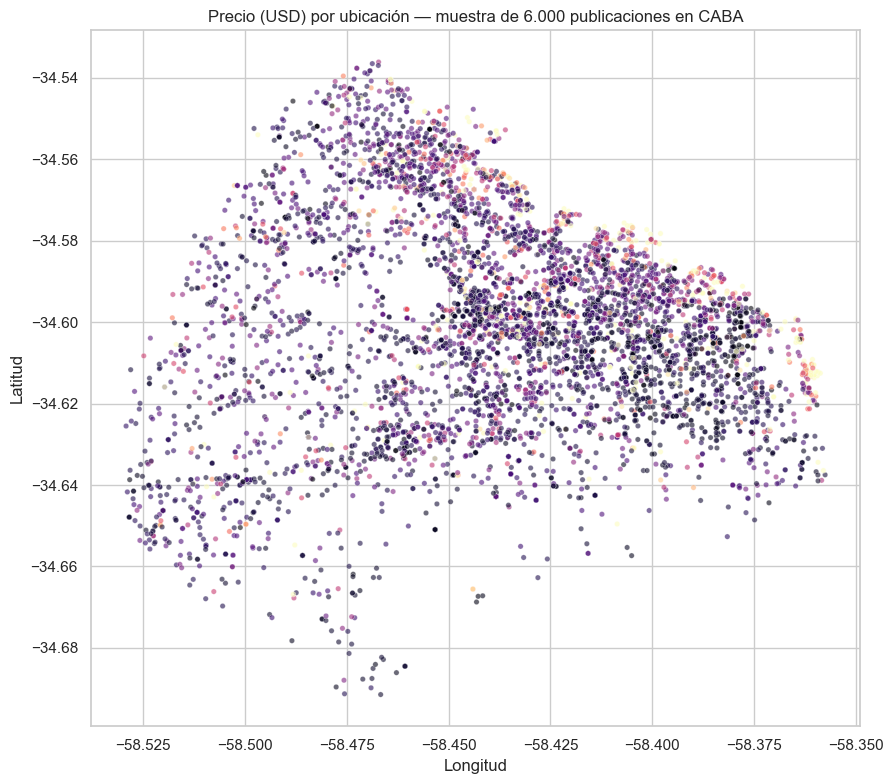

In [10]:
# Hallazgo de calidad de datos: las columnas están INVERTIDAS en el dataset.
# lat contiene -58.x (longitud real) y lon contiene -34.x (latitud real).
# Verificado en las primeras filas: lat=-58.4424, lon=-34.5736 = Colegiales, CABA.
print("lat (crudo) rango:", df["lat"].min(), "a", df["lat"].max())
print("lon (crudo) rango:", df["lon"].min(), "a", df["lon"].max())

df["lon_real"] = df["lat"]   # longitud correcta
df["lat_real"] = df["lon"]   # latitud correcta

# Límites geográficos plausibles de CABA
LAT_MIN, LAT_MAX = -34.71, -34.52
LON_MIN, LON_MAX = -58.54, -58.33

geo = df.dropna(subset=["lat_real", "lon_real", "price"]).copy()
fuera = ~geo["lat_real"].between(LAT_MIN, LAT_MAX) | ~geo["lon_real"].between(LON_MIN, LON_MAX)
print(f"Publicaciones con coordenadas fuera de CABA: {fuera.sum():,} de {len(geo):,} ({fuera.mean():.1%})")

muestra_geo = geo[~fuera].sample(n=6000, random_state=RANDOM_STATE)

fig, ax = plt.subplots(figsize=(9, 8))
sns.scatterplot(data=muestra_geo, x="lon_real", y="lat_real", hue="price",
                hue_norm=(0, muestra_geo["price"].quantile(0.95)),
                palette="magma", alpha=0.6, s=15, ax=ax, legend=False)
ax.set_title("Precio (USD) por ubicación — muestra de 6.000 publicaciones en CABA")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

**Qué descubrí:**
- **`lat` y `lon` están invertidas en el dataset**: `lat` guarda la longitud (-58.x) y `lon` la latitud (-34.x). Es un error de carga del dataset, no de las publicaciones. Se corrigió renombrando los valores (`lon_real`/`lat_real`). Sin esta corrección, cualquier modelo con coordenadas usaría los ejes al revés.
- **Hay coordenadas fuera de CABA** incluso tras corregir el swap: se imprimió el % arriba. Sirve como insumo para la limpieza de la parte 1b.
- Tras corregir, se ve la silueta de CABA. El color no muestra un gradiente fuerte: el precio no depende de lat/lon solamente, sino de **barrio** (`l3`), que es categórica. Eso sugiere usar `l3` (o los centroides por barrio) como feature en vez de confiar en una relación lineal con las coordenadas.